Dataset Shape: (50000, 20)
   user_id  age  gender country  account_age_months subscription_type  \
0  U100000   56    Male   India                  17          Standard   
1  U100001   46  Female     USA                  20          Standard   
2  U100002   32   Other     USA                  25             Basic   
3  U100003   60    Male  Canada                  37          Standard   
4  U100004   25    Male  Brazil                  23           Premium   

   monthly_fee payment_method primary_device  devices_used favorite_genre  \
0        15.99         PayPal         Laptop             1         Sci-Fi   
1        12.99         PayPal         Tablet             2    Documentary   
2        15.99         PayPal         Tablet             2         Comedy   
3        12.99         PayPal       Smart TV             3         Action   
4        12.99         PayPal         Mobile             3         Horror   

   avg_watch_time_minutes  watch_sessions_per_week  binge_watch_session

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. 


RQ2 Results
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.8046   0.000000  0.000000  0.000000
1        Decision Tree    0.6580   0.184867  0.220061  0.200935
2        Random Forest    0.8046   0.000000  0.000000  0.000000


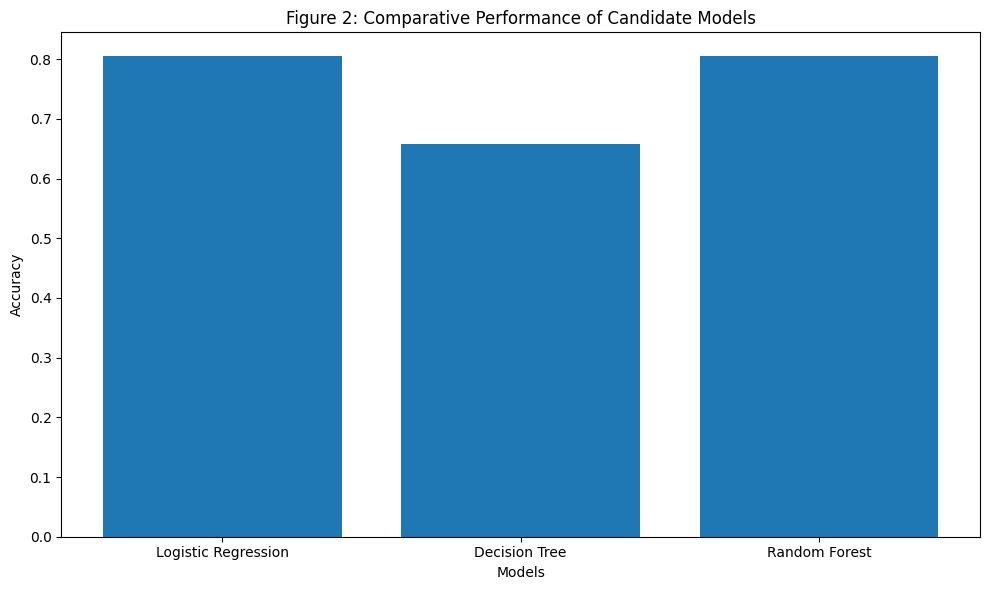


Saved Files:
RQ2_table.csv
RQ2_figure.pdf


In [1]:
# RQ2: Model Comparison
# Netflix User Churn Prediction
# ==========================================

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================================
# Step 2: Load dataset
# ==========================================

df = pd.read_csv(
    "/kaggle/input/datasets/sampath1092003/netflix-user-behavior-analysis-dataset/netflix_user_behavior_dataset.csv"
)

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# Step 3: Drop identifier column
# ==========================================

df.drop("user_id", axis=1, inplace=True)

# ==========================================
# Step 4: Encode categorical variables
# ==========================================

for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# ==========================================
# Step 5: Feature and target split
# ==========================================

X = df.drop("churned", axis=1)
y = df["churned"]

# ==========================================
# Step 6: Train-test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Step 7: Candidate models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=42
    )
}

# ==========================================
# Step 8: Train and evaluate
# ==========================================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# ==========================================
# Step 9: Create result table
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

print("\nRQ2 Results")
print(results_df)

# Save table
results_df.to_csv(
    "/kaggle/working/RQ2_table.csv",
    index=False
)

# ==========================================
# Step 10: Generate publication-style figure
# ==========================================

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Figure 2: Comparative Performance of Candidate Models")

plt.tight_layout()

# Save figure
plt.savefig(
    "/kaggle/working/RQ2_figure.pdf"
)

plt.show()

# ==========================================
# Step 11: Confirmation
# ==========================================

print("\nSaved Files:")
print("RQ2_table.csv")
print("RQ2_figure.pdf")